# Interactive Bandwidth Analysis
This notebook parses simulation logs and generates visualizations using Plotly.
Per-second distribution charts show stacked bars broken down by gossip topic.

In [22]:
import os
import re
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime

TOPIC_LABELS = {
    "/cl/beacon_block/1": "beacon_block",
    "/cl/payload_envelope/1": "payload_envelope",
    "/cl/blob_sidecar/1": "blob_sidecar",
    "/cl/ptc_attestation/1": "ptc_attestation",
    "/el/blob_hash/1": "blob_hash",
}

TOPIC_ORDER = [
    "beacon_block", "payload_envelope", "blob_sidecar",
    "ptc_attestation", "blob_hash", "req_res",
]

TOPIC_COLORS = {
    "beacon_block": "#636EFA",
    "payload_envelope": "#EF553B",
    "blob_sidecar": "#00CC96",
    "ptc_attestation": "#AB63FA",
    "blob_hash": "#FFA15A",
    "req_res": "#19D3F3",
}

def strip_ansi(text):
    return re.sub(r"\x1b\[[0-9;]*[mK]", "", text)

def get_peer_info():
    peer_data = []
    data_dir = "shadow.data/hosts"
    if not os.path.exists(data_dir):
        return pd.DataFrame(columns=["hostname", "roles"])
    for host in sorted(os.listdir(data_dir)):
        stdout_path = os.path.join(data_dir, host, "blob-sim.1000.stdout")
        if os.path.exists(stdout_path):
            with open(stdout_path, "r") as f:
                for line in f:
                    if "SUMMARY" in line:
                        line = strip_ansi(line)
                        m = re.search(r"(?:roles|persona)=([a-z0-9+_]+)", line)
                        if m:
                            peer_data.append({"hostname": host, "roles": m.group(1)})
                        break
    df = pd.DataFrame(peer_data)
    if df.empty:
        return pd.DataFrame(columns=["hostname", "roles"])
    return df

def parse_detailed_metrics(host, target_slot=1):
    log_path = f"shadow.data/hosts/{host}/blob-sim.1000.stdout"
    if not os.path.exists(log_path):
        return None
    re_ts = r"(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d+)Z"
    events = []
    slot_start_ts = None
    with open(log_path, "r") as f:
        for raw_line in f:
            line = strip_ansi(raw_line)
            ts_match = re.search(re_ts, line)
            if not ts_match:
                continue
            curr_ts = datetime.fromisoformat(ts_match.group(1))
            if "=== SLOT START ===" in line and f"slot={target_slot}" in line:
                slot_start_ts = curr_ts
                continue
            if slot_start_ts is None:
                continue
            rel_time = (curr_ts - slot_start_ts).total_seconds()
            if rel_time >= 12.0:
                break

            # Gossip messages: have topic= and msg_bytes=
            topic_match = re.search(r"topic=(/[^\s]+)", line)
            bytes_match = re.search(r"(forwarded_bytes|msg_bytes|req_bytes|resp_bytes)=(\d+)", line)
            if bytes_match:
                size = int(bytes_match.group(2))
                if "published" in line or "sending" in line or "response sent" in line or "forwarded" in line:
                    direction = "Outgoing"
                else:
                    direction = "Incoming"
                if topic_match:
                    raw_topic = topic_match.group(1)
                    topic = TOPIC_LABELS.get(raw_topic, raw_topic)
                else:
                    topic = "req_res"
                events.append({
                    "second": int(rel_time),
                    "direction": direction,
                    "topic": topic,
                    "bytes": size,
                })
    if not events:
        return None
    return pd.DataFrame(events)

def plot_per_second(host, target_slot=1):
    info = get_peer_info()
    role_row = info[info["hostname"] == host]
    role = role_row["roles"].iloc[0] if not role_row.empty else "unknown"

    df = parse_detailed_metrics(host, target_slot)
    if df is None or df.empty:
        print(f"No detailed data for {host}. (RUST_LOG=debug required)")
        return

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=[f"Incoming", f"Outgoing"],
        horizontal_spacing=0.08,
    )

    # Collect topics present in data, preserving canonical order
    present_topics = [t for t in TOPIC_ORDER if t in df["topic"].values]
    legend_added = set()

    for col_idx, direction in enumerate(["Incoming", "Outgoing"], 1):
        data = df[df["direction"] == direction]
        for topic in present_topics:
            topic_data = data[data["topic"] == topic]
            if topic_data.empty:
                grouped = pd.DataFrame({"second": range(12), "KB": 0.0})
            else:
                grouped = topic_data.groupby("second")["bytes"].sum().reset_index()
                grouped["KB"] = grouped["bytes"] / 1024
                all_secs = pd.DataFrame({"second": range(12)})
                grouped = pd.merge(all_secs, grouped, on="second", how="left").fillna(0)
            show_legend = topic not in legend_added
            legend_added.add(topic)
            fig.add_trace(
                go.Bar(
                    x=grouped["second"],
                    y=grouped["KB"],
                    name=topic,
                    marker_color=TOPIC_COLORS.get(topic, "#999999"),
                    showlegend=show_legend,
                    legendgroup=topic,
                ),
                row=1, col=col_idx,
            )

    fig.update_layout(
        barmode="stack",
        title_text=f"{host} ({role}) — Per-Second Bandwidth (Slot {target_slot})",
        height=400,
        legend_title_text="Topic",
    )
    fig.update_xaxes(title_text="Second", dtick=1)
    fig.update_yaxes(title_text="KB", col=1)
    fig.update_yaxes(title_text="KB", col=2)
    fig.show()
def parse_aggregate_metrics():
    metric_pattern = re.compile(
        r"METRIC slot=(\d+) (?:roles|persona)=([a-z0-9+_]+)"
        r" el_bytes_sent=(\d+) el_bytes_received=(\d+)"
        r" cl_bytes_sent=(\d+) cl_bytes_received=(\d+)"
    )
    data = []
    data_dir = "shadow.data/hosts"
    if not os.path.exists(data_dir):
        return pd.DataFrame()
    for host in os.listdir(data_dir):
        stdout_path = os.path.join(data_dir, host, "blob-sim.1000.stdout")
        if os.path.exists(stdout_path):
            with open(stdout_path, "r") as f:
                for line in f:
                    line = strip_ansi(line)
                    match = metric_pattern.search(line)
                    if match:
                        slot = int(match.group(1))
                        role = match.group(2)
                        data.append({"role": role, "Direction": "Outgoing", "Layer": "EL", "Bytes": int(match.group(3)), "slot": slot})
                        data.append({"role": role, "Direction": "Incoming", "Layer": "EL", "Bytes": int(match.group(4)), "slot": slot})
                        data.append({"role": role, "Direction": "Outgoing", "Layer": "CL", "Bytes": int(match.group(5)), "slot": slot})
                        data.append({"role": role, "Direction": "Incoming", "Layer": "CL", "Bytes": int(match.group(6)), "slot": slot})
    return pd.DataFrame(data)

def plot_aggregates(df, target_slot=1):
    if df.empty:
        print("No aggregate data found.")
        return
    slot_df = df[df["slot"] == target_slot]
    per_node = slot_df.groupby(["role", "Direction"])["Bytes"].mean().reset_index()
    per_node["KB"] = per_node["Bytes"] / 1024

    fig = go.Figure()
    colors = {"Incoming": "#636EFA", "Outgoing": "#EF553B"}
    for direction in ["Incoming", "Outgoing"]:
        subset = per_node[per_node["Direction"] == direction]
        fig.add_trace(go.Bar(
            x=subset["role"],
            y=subset["KB"],
            name=direction,
            marker_color=colors[direction],
        ))
    fig.update_layout(
        barmode="group",
        title_text=f"Average Bandwidth per Node by Role (Slot {target_slot})",
        xaxis_title="Role",
        yaxis_title="KB",
        height=450,
    )
    fig.show()

## Network Information & Peer Discovery
Analyze the network composition and find specific hostnames for detailed plotting.

In [23]:
info = get_peer_info()
if not info.empty:
    print(f"Total Peers in Network: {len(info)}")
    print("\nPeer Counts per Role Combination:")
    print(info["roles"].value_counts().to_string())
    print("\nHostname to Role Mapping (First 50):")
    display(info.head(50))
else:
    print("No peer data found. Ensure shadow.data/hosts/ exists.")

Total Peers in Network: 202

Peer Counts per Role Combination:
roles
provider        129
provider+ptc     41
sampler          21
sampler+ptc       9
builder           1
proposer          1

Hostname to Role Mapping (First 50):


,hostname,roles
0,builder,builder
1,proposer,proposer
2,provider1,provider+ptc
3,provider10,provider+ptc
4,provider100,provider
5,provider101,provider
6,provider102,provider
7,provider103,provider
8,provider104,provider
9,provider105,provider+ptc


## Per-Second Distribution (Slot 1)
Bandwidth utilization for specific nodes, stacked by gossip topic.

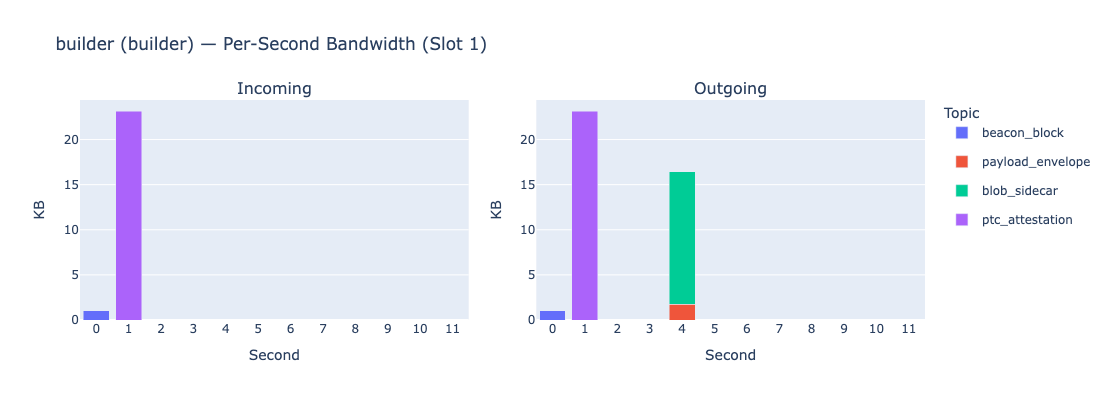

In [24]:
plot_per_second("builder")

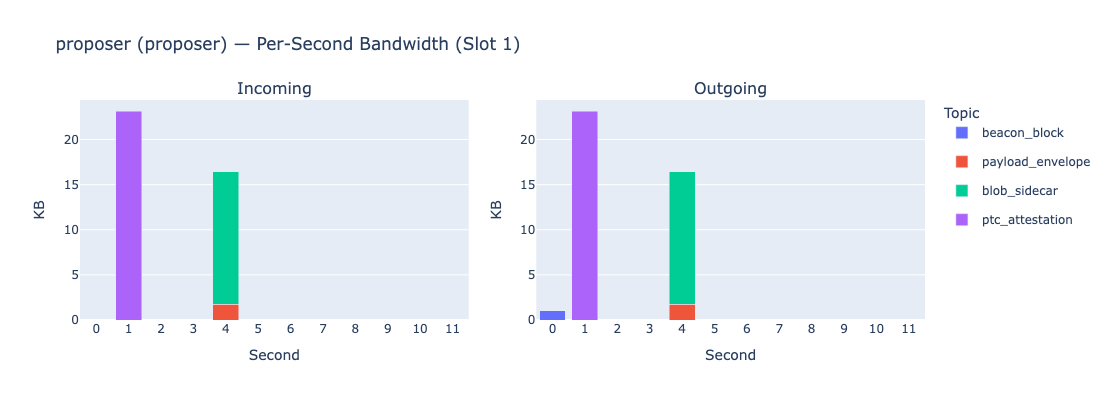

In [25]:
plot_per_second("proposer")

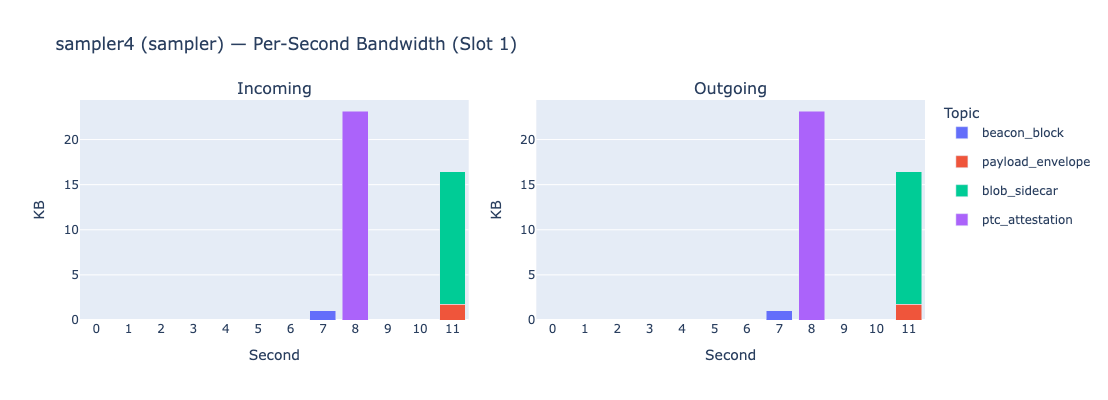

In [26]:
plot_per_second("sampler4")

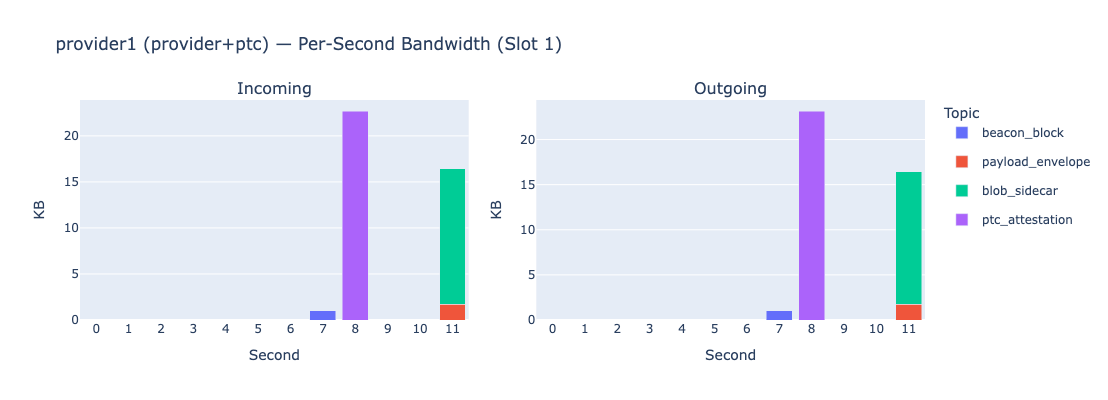

In [27]:
plot_per_second("provider1")

## Aggregate Cluster Analysis
Average bandwidth per node grouped by role combination.

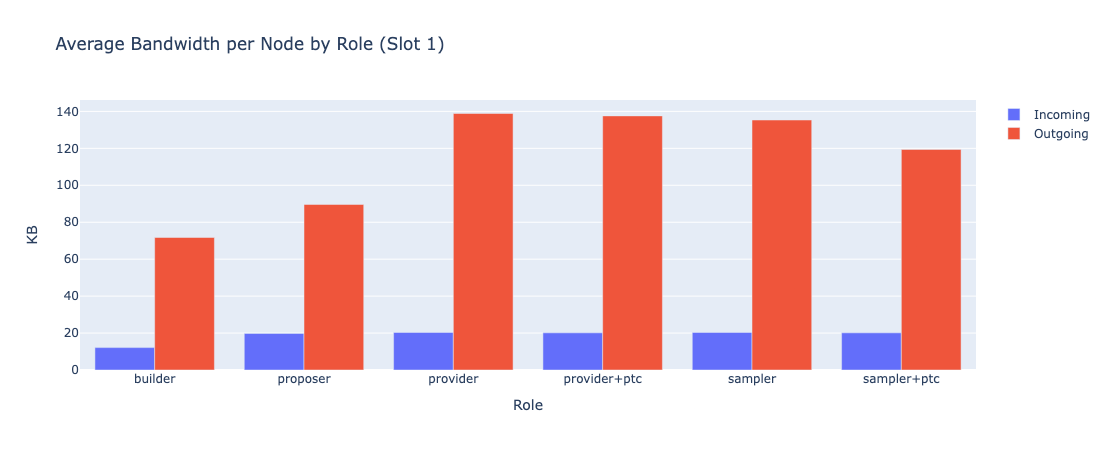

In [28]:
df = parse_aggregate_metrics()
plot_aggregates(df)